--- Generating MONTHLY Comparative Chart: ABM vs SARIMA vs LSTM ---
--- Using SUM of monthly consumption (not annual average) ---
ABM scenarios loaded: 18 scenarios, 120 monthly records
SARIMA data loaded: 120 monthly records
LSTM data loaded: 120 monthly records
LSTM consumption range: 173567 - 186941 m³/month
Color map created for 18 scenarios
CXIII color = (np.float64(0.8901960784313725), np.float64(0.4666666666666667), np.float64(0.7607843137254902), np.float64(1.0))



✓ Success! Monthly comparison chart saved at: ..\figuras\figure-result-simulation-final-comparison-monthly-labels.pdf

--- Statistical Summary (Monthly Raw Consumption) ---

SARIMA forecast (2026-2035):
  Mean: 188.7k m³
  Min: 174.9k m³
  Max: 199.1k m³

LSTM forecast (2026-2035):
  Mean: 180.0k m³
  Min: 173.6k m³
  Max: 186.9k m³

ABM scenarios (2026-2035):
  Mean (all scenarios): 187.7k m³
  Std deviation: 3.4k m³
  Min: 183.3k m³
  Max: 196.5k m³


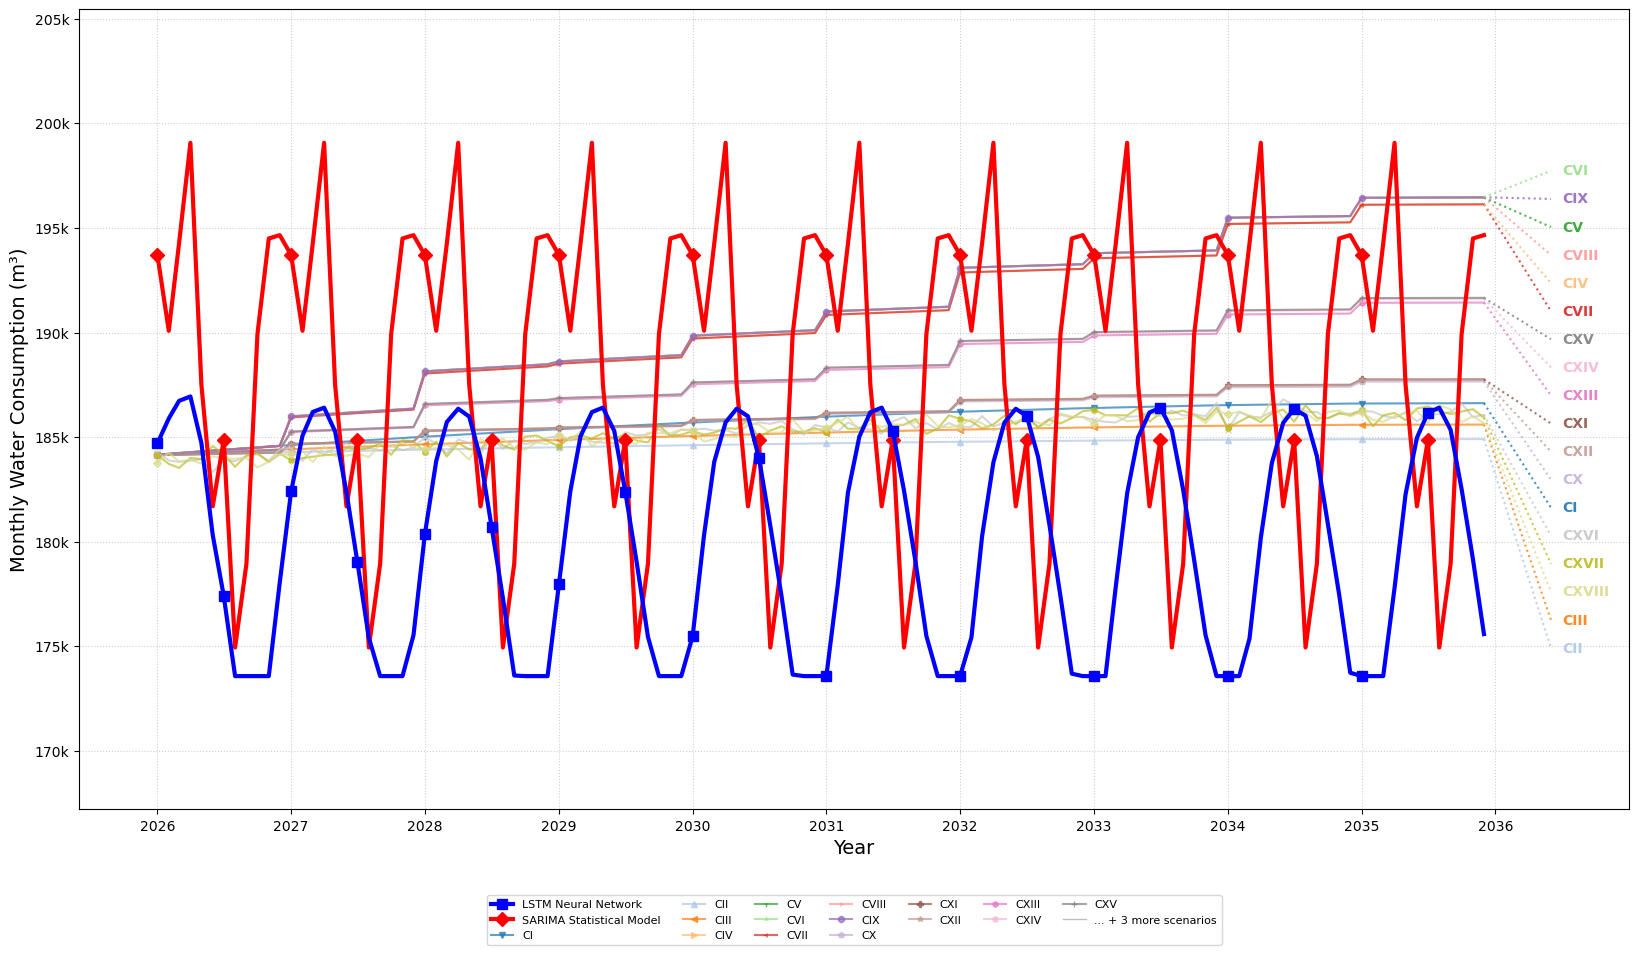

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import numpy as np
import os
from matplotlib.colors import to_rgba

# ==========================================
# 1. Configurations and Paths
# ==========================================
BASE_PATH = '..' 

np.random.seed(42)  # FIXED SEED for consistent colors

# Input Filenames
SCENARIO_FILE = 'consumo_previsto_todos_cenarios_2026_2035.csv'
LSTM_FILE = 'previsoes_futuras_2026_2035.csv'
SARIMA_FILE = 'previsao_consumo_sarima_2026_2035.csv'

# Output Configuration
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')
OUTPUT_FIG = 'figure-result-simulation-final-comparison-monthly-labels.pdf'

# Figure size configuration
FIGURE_WIDTH = 20
FIGURE_HEIGHT = 10

# Search Directories
INPUT_DIR_RESULTS = os.path.join(BASE_PATH, 'resultados')
INPUT_DIR_MODELS = os.path.join(BASE_PATH, 'modelos IA')

def roman_to_value(roman):
    """Convert Roman numeral to numeric value for proper sorting"""
    roman_values = {
        'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'V': 5,
        'VI': 6, 'VII': 7, 'VIII': 8, 'IX': 9, 'X': 10,
        'XI': 11, 'XII': 12, 'XIII': 13, 'XIV': 14, 'XV': 15,
        'XVI': 16, 'XVII': 17, 'XVIII': 18, 'XIX': 19, 'XX': 20
    }
    # Extract the Roman part after 'C'
    if roman.startswith('C'):
        roman_part = roman[1:]
        return roman_values.get(roman_part, 999)
    return 999

def main():
    print("--- Generating MONTHLY Comparative Chart: ABM vs SARIMA vs LSTM ---")
    print("--- Using SUM of monthly consumption (not annual average) ---")

    # ==========================================
    # 2. Data Loading and Preparation
    # ==========================================
    
    # A. Load ABM Scenarios
    path_scen = os.path.join(INPUT_DIR_RESULTS, SCENARIO_FILE)
    df_scenarios = pd.read_csv(path_scen, sep=';', decimal=',')
    
    # Create Date column from Mes and Ano
    if 'Mes' in df_scenarios.columns and 'Ano' in df_scenarios.columns:
        df_scenarios['Date'] = pd.to_datetime(
            df_scenarios['Ano'].astype(str) + '-' + 
            df_scenarios['Mes'].astype(str) + '-01'
        )
    
    # Identify scenario columns (exclude metadata columns)
    exclude_cols = ['Mes', 'Ano', 'Mes_Ano', 'Date']
    scenario_cols = [c for c in df_scenarios.columns if c not in exclude_cols]
    
    # Filter to desired period (2026-2035)
    df_scenarios = df_scenarios[(df_scenarios['Date'] >= '2026-01-01') & (df_scenarios['Date'] <= '2035-12-31')]
    print(f"ABM scenarios loaded: {len(scenario_cols)} scenarios, {len(df_scenarios)} monthly records")
    
    # Convert scenario values to numeric (they have comma as decimal)
    for col in scenario_cols:
        df_scenarios[col] = pd.to_numeric(df_scenarios[col], errors='coerce')

    # B. Load SARIMA Forecast
    path_sarima = os.path.join(INPUT_DIR_MODELS, SARIMA_FILE)
    df_sarima = None
    if os.path.exists(path_sarima):
        df_sarima = pd.read_csv(path_sarima)
        
        # Detect date column
        if 'Date' in df_sarima.columns:
            df_sarima['Date'] = pd.to_datetime(df_sarima['Date'])
        elif 'data' in df_sarima.columns:
            df_sarima['Date'] = pd.to_datetime(df_sarima['data'])
        
        # Identify forecast column
        if 'Projected_Consumption' in df_sarima.columns:
            df_sarima.rename(columns={'Projected_Consumption': 'SARIMA'}, inplace=True)
        elif 'forecast' in df_sarima.columns:
            df_sarima.rename(columns={'forecast': 'SARIMA'}, inplace=True)
        
        df_sarima = df_sarima[(df_sarima['Date'] >= '2026-01-01') & (df_sarima['Date'] <= '2035-12-31')]
        print(f"SARIMA data loaded: {len(df_sarima)} monthly records")
    else:
        print(f"Aviso: {SARIMA_FILE} não encontrado em {path_sarima}")

    # C. Load LSTM Forecast
    path_lstm = os.path.join(INPUT_DIR_MODELS, LSTM_FILE)
    df_lstm = None
    if os.path.exists(path_lstm):
        df_lstm = pd.read_csv(path_lstm, sep=",")
        
        # Detect date column (different possible names)
        if 'Data' in df_lstm.columns:
            df_lstm['Date'] = pd.to_datetime(df_lstm['Data'])
        elif 'date' in df_lstm.columns:
            df_lstm['Date'] = pd.to_datetime(df_lstm['date'])
        elif 'mes' in df_lstm.columns and 'ano' in df_lstm.columns:
            df_lstm['Date'] = pd.to_datetime(
                df_lstm['ano'].astype(str) + '-' + 
                df_lstm['mes'].astype(str) + '-01'
            )
        
        # Identify forecast column
        if 'Valor Previsto' in df_lstm.columns:
            df_lstm.rename(columns={'Valor Previsto': 'LSTM'}, inplace=True)
        elif 'predicted' in df_lstm.columns:
            df_lstm.rename(columns={'predicted': 'LSTM'}, inplace=True)
        elif 'LSTM' in df_lstm.columns:
            pass  # Already has correct name
        
        # Convert to numeric if needed
        if 'LSTM' in df_lstm.columns:
            df_lstm['LSTM'] = pd.to_numeric(df_lstm['LSTM'], errors='coerce')
        
        df_lstm = df_lstm[(df_lstm['Date'] >= '2026-01-01') & (df_lstm['Date'] <= '2035-12-31')]
        print(f"LSTM data loaded: {len(df_lstm)} monthly records")
        if len(df_lstm) > 0:
            print(f"LSTM consumption range: {df_lstm['LSTM'].min():.0f} - {df_lstm['LSTM'].max():.0f} m³/month")
    else:
        print(f"Aviso: {LSTM_FILE} não encontrado em {path_lstm}")

    # ==========================================
    # 3. Generate CONSISTENT colors for scenarios
    # ==========================================
    
    # Extract scenario IDs (short names like CI, CII, C0, etc.)
    scenario_ids = []
    for col in scenario_cols:
        scen_id = col.split('_')[0] if '_' in col else col[:4]
        scenario_ids.append(scen_id)
    
    # Get unique scenario IDs and sort by Roman numeral order
    unique_scenario_ids = list(dict.fromkeys(scenario_ids))  # Preserve order but ensure uniqueness
    scenario_order = sorted(unique_scenario_ids, key=roman_to_value)
    
    # Generate colors using tab20 with FIXED sequence
    # Using fixed indices guarantees same colors across different scripts
    tab20_colors = [plt.cm.tab20(i) for i in range(20)]
    color_map = {scenario: tab20_colors[i % 20] for i, scenario in enumerate(scenario_order)}
    
    print(f"Color map created for {len(color_map)} scenarios")
    # Debug: print color for a specific scenario if exists
    if 'CXIII' in color_map:
        print(f'CXIII color = {color_map["CXIII"]}')

    # ==========================================
    # 4. Plotting (MONTHLY - RAW VALUES)
    # ==========================================
    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))

    # --- ABM Scenarios Cloud (Monthly - RAW VALUES) ---
    markers_list = ['v', '^', '<', '>', '1', '2', '3', '4', '8', 'p', 'P', '*', 'h', 'H', '+', 'x', 'X', 'D']
    
    # Plot all scenarios using the color map
    for idx, col in enumerate(scenario_cols):
        scen_id = col.split('_')[0] if '_' in col else col[:4]
        ax.plot(df_scenarios['Date'], df_scenarios[col], 
                label=scen_id, color=color_map[scen_id],
                linestyle='-', linewidth=1.5, alpha=0.7, 
                marker=markers_list[idx % len(markers_list)], 
                markersize=4, markevery=12, zorder=5)

    # --- SARIMA Forecast (Red) ---
    if df_sarima is not None and len(df_sarima) > 0:
        ax.plot(df_sarima['Date'], df_sarima['SARIMA'], 
                label='SARIMA Statistical Model', color='red',
                linestyle='-', linewidth=3.0, 
                marker='D', markersize=7, markevery=6, zorder=20)

    # --- LSTM Forecast (Blue) ---
    if df_lstm is not None and len(df_lstm) > 0:
        ax.plot(df_lstm['Date'], df_lstm['LSTM'], 
                label='LSTM Neural Network', color='blue',
                linestyle='-', linewidth=3.0, 
                marker='s', markersize=7, markevery=6, zorder=21)

    # Find max values to adjust label positions
    all_values = []
    for col in scenario_cols:
        all_values.extend(df_scenarios[col].values)
    
    if df_lstm is not None:
        all_values.extend(df_lstm['LSTM'].values)
    if df_sarima is not None:
        all_values.extend(df_sarima['SARIMA'].values)
    
    y_max_all = max(all_values)
    y_min_all = min(all_values)
    y_range = y_max_all - y_min_all
    
    # ==========================================
    # 5. Add Labels at the End of Scenario Lines (separated to avoid overlap)
    # ==========================================
    last_date = df_scenarios['Date'].iloc[-1]
    # Create an extended date for label positioning (2036)
    extended_date = pd.Timestamp('2036-06-01')
    
    # Sort scenarios by their final value to organize labels vertically
    scenario_final_values = []
    for idx, col in enumerate(scenario_cols):
        scen_id = col.split('_')[0] if '_' in col else col[:4]
        last_value = df_scenarios[col].iloc[-1]
        scenario_final_values.append((scen_id, last_value, idx, col))
    
    # Sort by final value to arrange labels in order
    scenario_final_values.sort(key=lambda x: x[1])
    
    # Calculate vertical spacing based on number of scenarios and y-range
    n_scenarios = len(scenario_final_values)
    vertical_spacing = y_range / (n_scenarios + 1)
    
    for position, (scen_id, last_value, original_idx, col) in enumerate(scenario_final_values):
        # Calculate y position for label (evenly spaced)
        if n_scenarios > 1:
            y_label_pos = y_min_all + (position + 1) * vertical_spacing
        else:
            y_label_pos = last_value
        
        # Add line from end of curve to label position
        ax.plot([last_date, extended_date], [last_value, y_label_pos], 
                color=color_map[scen_id], linestyle=':', linewidth=1.5, alpha=0.8, zorder=15)
        
        # Add text label at extended position
        ax.annotate(scen_id, 
                   xy=(extended_date, y_label_pos),
                   xytext=(8, 0),
                   textcoords="offset points",
                   fontsize=10,
                   color=color_map[scen_id],
                   fontweight='bold',
                   alpha=0.9,
                   zorder=25,
                   va='center')

    # ==========================================
    # 6. Final Formatting
    # ==========================================
    ax.set_ylabel('Monthly Water Consumption (m³)', fontsize=14)
    ax.set_xlabel('Year', fontsize=14)
    
    # Format x-axis: show every year
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    # Format y-axis with 'k' suffix (thousands)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}k'))
    
    # Set x-axis limits - expanded to 2036 to show labels
    ax.set_xlim(pd.Timestamp('2025-06-01'), pd.Timestamp('2036-12-31'))
    
    # Set y-axis limits with increased margin for labels (25% margin)
    y_margin = y_range * 0.25
    ax.set_ylim(y_min_all - y_margin, y_max_all + y_margin)
    
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Legend - reordered to show main models first
    handles, labels = ax.get_legend_handles_labels()
    main_order = ['LSTM Neural Network', 'SARIMA Statistical Model']
    
    new_handles = []
    new_labels = []
    for m in main_order:
        if m in labels:
            idx = labels.index(m)
            new_handles.append(handles[idx])
            new_labels.append(labels[idx])
    
    # Add scenarios to legend (limit to avoid overcrowding)
    scenario_count = 0
    for i, l in enumerate(labels):
        if l not in main_order and scenario_count < 15:
            new_handles.append(handles[i])
            new_labels.append(l)
            scenario_count += 1
    
    if len(scenario_cols) > 15:
        new_labels.append(f'... + {len(scenario_cols)-15} more scenarios')
        new_handles.append(plt.Line2D([0], [0], color='gray', linestyle='-', linewidth=1, alpha=0.5))
    
    plt.legend(new_handles, new_labels, loc='upper center', bbox_to_anchor=(0.5, -0.10), 
               ncol=7, fontsize=8, frameon=True)
    
    plt.subplots_adjust(bottom=0.15, top=0.95, right=0.90)
    
    # Save
    if not os.path.exists(OUTPUT_DIR): 
        os.makedirs(OUTPUT_DIR)
    save_path = os.path.join(OUTPUT_DIR, OUTPUT_FIG)
    plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
    
    print(f"\n✓ Success! Monthly comparison chart saved at: {save_path}")
    
    # ==========================================
    # 7. Statistical Summary
    # ==========================================
    print("\n--- Statistical Summary (Monthly Raw Consumption) ---")
    
    if df_sarima is not None:
        print(f"\nSARIMA forecast (2026-2035):")
        print(f"  Mean: {df_sarima['SARIMA'].mean()/1000:.1f}k m³")
        print(f"  Min: {df_sarima['SARIMA'].min()/1000:.1f}k m³")
        print(f"  Max: {df_sarima['SARIMA'].max()/1000:.1f}k m³")
    
    if df_lstm is not None:
        print(f"\nLSTM forecast (2026-2035):")
        print(f"  Mean: {df_lstm['LSTM'].mean()/1000:.1f}k m³")
        print(f"  Min: {df_lstm['LSTM'].min()/1000:.1f}k m³")
        print(f"  Max: {df_lstm['LSTM'].max()/1000:.1f}k m³")
    
    # Calculate ABM scenario statistics
    abm_values = []
    for col in scenario_cols:
        abm_values.extend(df_scenarios[col].values)
    print(f"\nABM scenarios (2026-2035):")
    print(f"  Mean (all scenarios): {np.mean(abm_values)/1000:.1f}k m³")
    print(f"  Std deviation: {np.std(abm_values)/1000:.1f}k m³")
    print(f"  Min: {np.min(abm_values)/1000:.1f}k m³")
    print(f"  Max: {np.max(abm_values)/1000:.1f}k m³")
    
    plt.show()

if __name__ == "__main__":
    main()